In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt  


In [3]:
df = pd.read_csv("Bengaluru_House_Data.csv")
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [4]:
df.shape

(13320, 9)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 1.6 MB


In [6]:
df.duplicated().sum()

np.int64(529)

In [7]:
df=df.drop_duplicates()

In [8]:
df.isna().sum()

area_type          0
availability       0
location           1
size              16
society         5328
total_sqft         0
bath              73
balcony          605
price              0
dtype: int64

# data overview 

In [9]:
df["area_type"].value_counts()

area_type
Super built-up  Area    8317
Built-up  Area          2398
Plot  Area              1989
Carpet  Area              87
Name: count, dtype: int64

In [10]:
df["availability"].value_counts().sum

<bound method Series.sum of availability
Ready To Move    10172
18-May             292
18-Dec             284
18-Apr             269
18-Aug             187
                 ...  
15-Aug               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 81, dtype: int64>

In [11]:
df["location"].value_counts()

location
Whitefield                                         523
Sarjapur  Road                                     379
Electronic City                                    287
Kanakpura Road                                     249
Thanisandra                                        229
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12th cross srinivas nagar banshankari 3rd stage      1
Havanur extension                                    1
Abshot Layout                                        1
Name: count, Length: 1305, dtype: int64

In [12]:
df["location"].nunique()

1305

we have 1 row with null values in the location column and there are 1305 unique values so  we can drop the row 

In [13]:
df["size"].value_counts() 
# we can remove BHK and bedroom from the  columns to convert them to nummeric   


size
2 BHK         4931
3 BHK         4120
4 Bedroom      824
4 BHK          574
3 Bedroom      535
1 BHK          521
2 Bedroom      314
5 Bedroom      291
6 Bedroom      191
1 Bedroom      104
8 Bedroom       84
7 Bedroom       82
5 BHK           59
9 Bedroom       46
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            8
8 BHK            5
11 BHK           2
11 Bedroom       2
10 BHK           2
27 BHK           1
19 BHK           1
16 BHK           1
43 Bedroom       1
14 BHK           1
12 Bedroom       1
13 BHK           1
18 Bedroom       1
Name: count, dtype: int64

In [14]:
df["society"].value_counts()

society
GrrvaGr    68
PrarePa    63
Sryalan    56
Prtates    54
GMown E    52
           ..
Maa 5a      1
AeisePV     1
SJovest     1
ThhtsV      1
RSntsAp     1
Name: count, Length: 2688, dtype: int64

In [15]:
df["society"].nunique()

2688

In [16]:
df.describe()

,bath,balcony,price
count,12718.000000,12186.000000,12791.000000
mean,2.708602,1.582308,114.317646
std,1.357764,0.822536,151.480310
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,73.000000
75%,3.000000,2.000000,121.000000
max,40.000000,3.000000,3600.000000


In [17]:
df.describe(include="object")

C:\Users\pushk\AppData\Local\Temp\ipykernel_8136\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,area_type,availability,location,size,society,total_sqft
count,12791,12791,12790,12775,7463,12791
unique,4,81,1305,31,2688,2117
top,Super built-up Area,Ready To Move,Whitefield,2 BHK,GrrvaGr,1200
freq,8317,10172,523,4931,68,808


here total_sqft is in str which we need to convert it to the  integers 

# Data cleaning 

In [18]:
df = df.replace('NaN', np.nan)

In [19]:
df["total_sqft"].value_counts()

total_sqft
1200           808
1100           210
1500           202
2400           196
600            178
              ... 
1020 - 1130      1
2758             1
1133 - 1384      1
774              1
4689             1
Name: count, Length: 2117, dtype: int64

In [20]:
def clean_total_sqft(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip()
    if "perch" in x.lower():
        num_str = x.lower().replace("perch", "").strip()
        return pd.to_numeric(num_str) * 272.25
    if "sq. yards" in x.lower():
        num_str = x.lower().replace("sq. yards", "").strip()
        return pd.to_numeric(num_str) * 9.0
    if "acre" in x.lower():
        num_str = x.lower().replace("acres", "").replace("acre", "").strip()
        return pd.to_numeric(num_str) * 43560.0
    if "sq. meter" in x.lower():
        num_str = x.lower().replace("sq. meter", "").strip()
        return pd.to_numeric(num_str) * 10.7639
    if "cent" in x.lower():
        num_str = x.lower().replace("cents", "").replace("cent", "").strip()
        return pd.to_numeric(num_str) * 435.6
    if "ground" in x.lower():
        num_str = x.lower().replace("grounds", "").replace("ground", "").strip()
        return pd.to_numeric(num_str) * 2400.0
    if "guntha" in x.lower():
        num_str = x.lower().replace("guntha", "").strip()
        return pd.to_numeric(num_str) * 1089.0
    if "-" in x:
        parts = x.split("-")
        v1 = pd.to_numeric(parts[0].strip())
        v2 = pd.to_numeric(parts[1].strip())
        return (v1 + v2) / 2.0
    return pd.to_numeric(x)

In [21]:
df["total_sqft"] = df["total_sqft"].apply(clean_total_sqft)

In [22]:
df["total_sqft"].value_counts()

total_sqft
1200.0    808
1100.0    210
1500.0    203
2400.0    197
600.0     178
         ... 
2395.0      1
2758.0      1
1258.5      1
774.0       1
4689.0      1
Name: count, Length: 2034, dtype: int64

In [23]:
df.loc[df["location"].isna()]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
568,Super built-up Area,Ready To Move,NaN,3 BHK,Grare S,1600.0,3.0,2.0,86.0


In [24]:
df.loc[df["society"]=="Grare S"]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
568,Super built-up Area,Ready To Move,NaN,3 BHK,Grare S,1600.0,3.0,2.0,86.0
12238,Carpet Area,Ready To Move,Anantapura,3 BHK,Grare S,1600.0,3.0,2.0,77.0


In [25]:
df["location"] = df["location"].fillna("Anantapura")

In [26]:
df.loc[df["location"].isna()]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price


In [27]:
df["size"].isna().sum()

np.int64(16)

In [28]:
df.loc[df["size"].isna()]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
579,Plot Area,Immediate Possession,Sarjapur Road,NaN,Asiss B,1800.0,NaN,NaN,34.185
1775,Plot Area,Immediate Possession,IVC Road,NaN,Orana N,3817.0,NaN,NaN,124.000
2264,Plot Area,Immediate Possession,Banashankari,NaN,NaN,2400.0,NaN,NaN,460.000
2809,Plot Area,Immediate Possession,Sarjapur Road,NaN,AsdiaAr,1800.0,NaN,NaN,28.785
2862,Plot Area,Immediate Possession,Devanahalli,NaN,Ajleyor,1950.0,NaN,NaN,46.800
5333,Plot Area,Immediate Possession,Devanahalli,NaN,Emngs S,3752.5,NaN,NaN,177.115
6423,Plot Area,Immediate Possession,Whitefield,NaN,SRniaGa,2324.0,NaN,NaN,26.730
6636,Plot Area,Immediate Possession,Jigani,NaN,S2enste,1500.0,NaN,NaN,25.490
6719,Plot Area,Immediate Possession,Hoskote,NaN,SJowsn,1730.0,NaN,NaN,28.545
7680,Plot Area,Immediate Possession,Kasavanhalli,NaN,NaN,5000.0,NaN,NaN,400.000


In [29]:
df = df[df["size"].notna()]

In [30]:
df["size"].isna().sum()

np.int64(0)

In [31]:
def extract_bhk_components(x):
    cols = ["bedrooms", "halls", "kitchens"]
    if pd.isna(x):
        return pd.Series([np.nan] * 3, index=cols)
    parts = str(x).strip().split()
    if not parts:
        return pd.Series([np.nan] * 3, index=cols)
    num = pd.to_numeric(parts[0], errors="coerce")
    unit = " ".join(parts[1:]).lower()
    if "rk" in unit:
        values = [0, 0, 1]
    elif any(k in unit for k in ["bhk", "bedroom"]):
        values = [num, 1, 1]
    else:
        values = [num, np.nan, np.nan]
    return pd.Series(values, index=cols)

In [32]:
df[["bedrooms", "halls", "kitchens"]] = df["size"].apply(extract_bhk_components)

In [33]:
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bedrooms,halls,kitchens
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056.0,2.0,1.0,39.07,2,1,1
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600.0,5.0,3.0,120.00,4,1,1
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440.0,2.0,3.0,62.00,3,1,1
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521.0,3.0,1.0,95.00,3,1,1
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200.0,2.0,1.0,51.00,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
13314,Super built-up Area,Ready To Move,Green Glen Layout,3 BHK,SoosePr,1715.0,3.0,3.0,112.00,3,1,1
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453.0,4.0,0.0,231.00,5,1,1
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600.0,5.0,NaN,400.00,4,1,1
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141.0,2.0,1.0,60.00,2,1,1


In [34]:
df.loc[df["bath"].isna()]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bedrooms,halls,kitchens
56,Built-up Area,20-Feb,Devanahalli,4 Bedroom,BrereAt,3210.0,NaN,NaN,192.000,4,1,1
81,Built-up Area,18-Oct,Hennur Road,4 Bedroom,Gollela,3203.5,NaN,NaN,224.500,4,1,1
224,Super built-up Area,19-Dec,Devanahalli,3 BHK,Jurdsig,1630.0,NaN,NaN,74.820,3,1,1
344,Super built-up Area,21-Dec,Kanakpura Road,1 BHK,PrarePa,525.0,NaN,NaN,21.530,1,1,1
669,Super built-up Area,18-Dec,JP Nagar,5 BHK,Pehtsa,5520.0,NaN,NaN,375.000,5,1,1
702,Super built-up Area,18-Dec,JP Nagar,5 BHK,Pehtsa,5600.0,NaN,NaN,548.500,5,1,1
801,Super built-up Area,18-Dec,JP Nagar,4 BHK,Pehtsa,4624.5,NaN,NaN,453.000,4,1,1
941,Super built-up Area,Ready To Move,Whitefield,4 Bedroom,PrOakSi,4348.5,NaN,NaN,304.000,4,1,1
1264,Built-up Area,18-May,Hennur,3 Bedroom,Asoilul,2264.0,NaN,NaN,155.000,3,1,1
1267,Super built-up Area,18-Jun,Yelahanka,3 BHK,Shalkri,1662.0,NaN,NaN,67.980,3,1,1


In [35]:
df["bath"] = df["bath"].fillna(-1)

In [36]:
df["bath"].isna().sum()

np.int64(0)

In [37]:
df["balcony"] = df["balcony"].fillna(-1)

In [38]:
df.isna().sum()

area_type          0
availability       0
location           0
size               0
society         5325
total_sqft         0
bath               0
balcony            0
price              0
bedrooms           0
halls              0
kitchens           0
dtype: int64

In [39]:
df=df.drop("size",axis=1)

In [40]:
df["society"].isna().sum()/len(df)

np.float64(0.41682974559686886)

In [41]:
loc_to_society_mode = df.groupby("location")["society"].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
)

In [42]:
df["society"] = df["society"].fillna(df["location"].map(loc_to_society_mode))

In [43]:
df["society"].isna().sum()

np.int64(1385)

In [44]:
df["society"] = df["society"].fillna("unknown")

In [45]:
df["society"].isna().sum()

np.int64(0)

In [46]:
df["area_type"].value_counts()

area_type
Super built-up  Area    8317
Built-up  Area          2398
Plot  Area              1973
Carpet  Area              87
Name: count, dtype: int64

In [47]:
df["availability"].value_counts()

availability
Ready To Move    10172
18-May             292
18-Dec             284
18-Apr             269
18-Aug             187
                 ...  
15-Aug               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 80, dtype: int64

In [48]:
df["availability"] = np.where(df["availability"].str.strip().isin(["Ready To Move", "Immediate Possession"]),"Ready", "Upcoming")

In [49]:
df["availability"]

0        Upcoming
1           Ready
2           Ready
3           Ready
4           Ready
           ...   
13314       Ready
13315       Ready
13316       Ready
13317       Ready
13318    Upcoming
Name: availability, Length: 12775, dtype: str

# Univariate Analysis

In [50]:
num_col = df.describe().columns
cat_cols = df.describe(include="object").columns

C:\Users\pushk\AppData\Local\Temp\ipykernel_8136\2076273583.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.describe(include="object").columns


In [51]:
num_col,cat_cols

(Index(['total_sqft', 'bath', 'balcony', 'price', 'bedrooms', 'halls',
        'kitchens'],
       dtype='str'),
 Index(['area_type', 'availability', 'location', 'society'], dtype='str'))

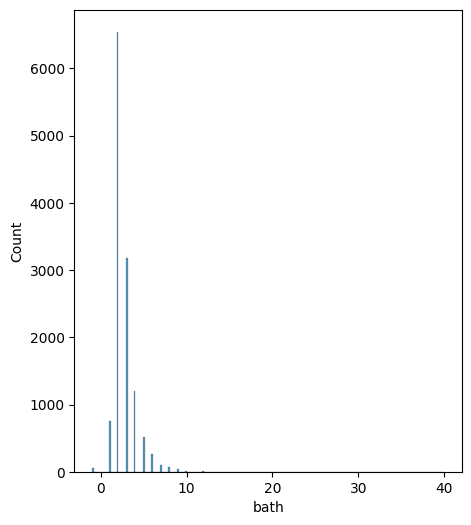

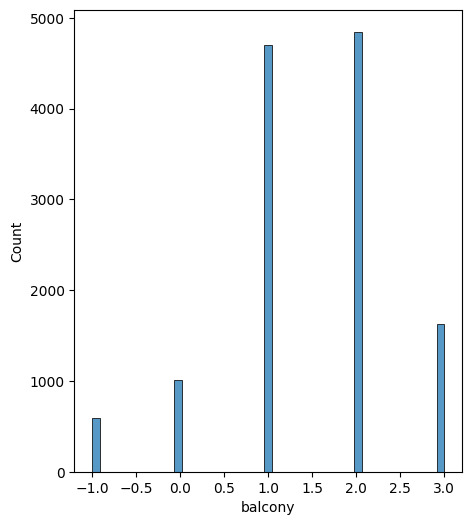

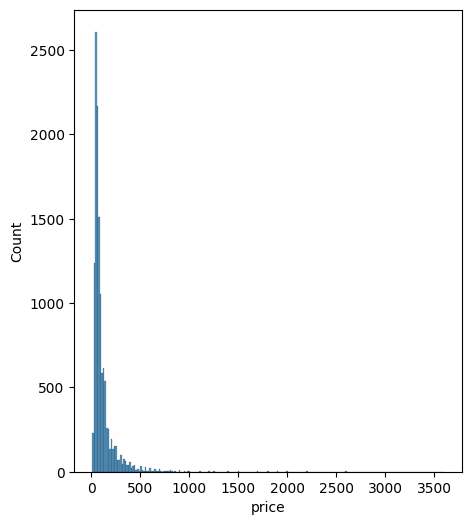

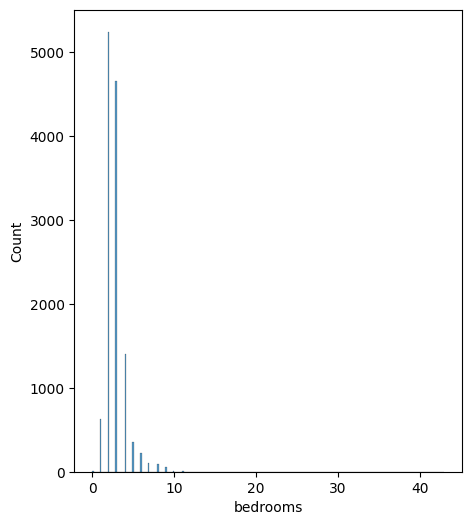

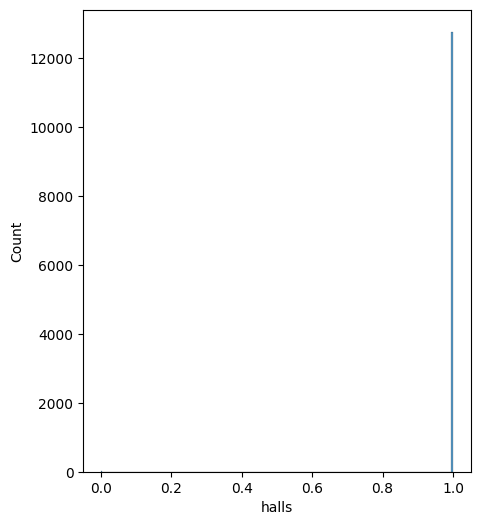

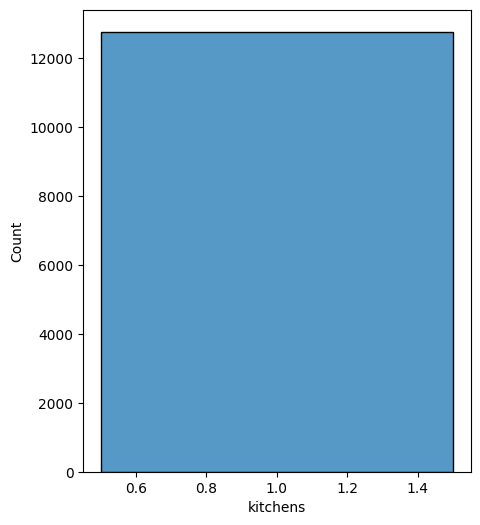

In [52]:
for i in ['bath', 'balcony', 'price', 'bedrooms', 'halls',
        'kitchens']:
    plt.figure(figsize=(5,6))
    sns.histplot(df[i])

<Axes: ylabel='price'>

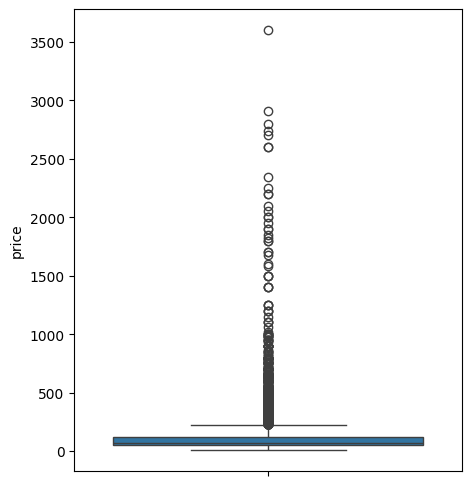

In [53]:
plt.figure(figsize=(5,6))
sns.boxplot(df["price"])

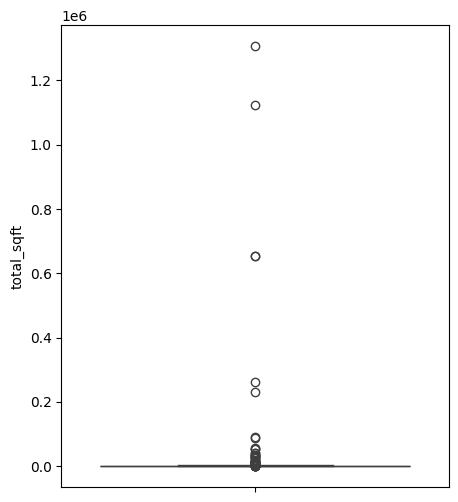

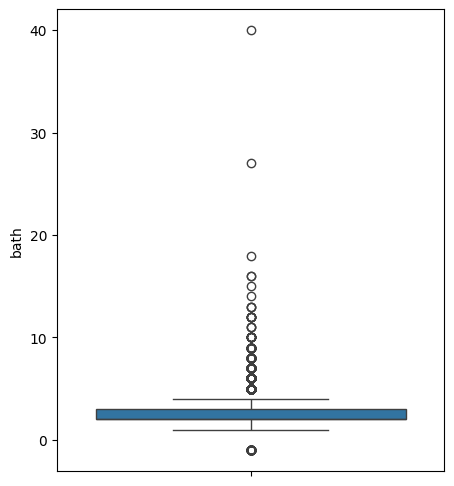

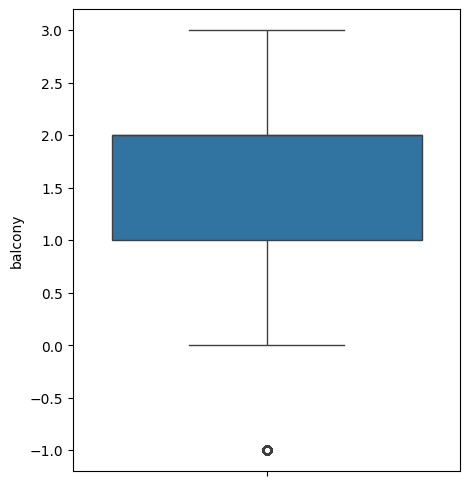

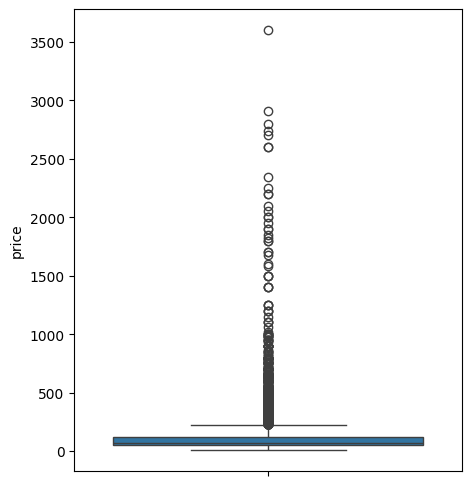

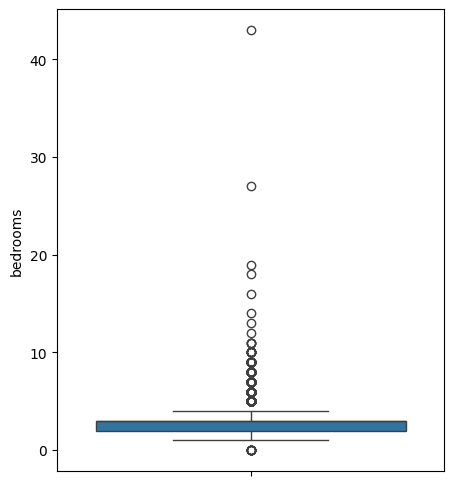

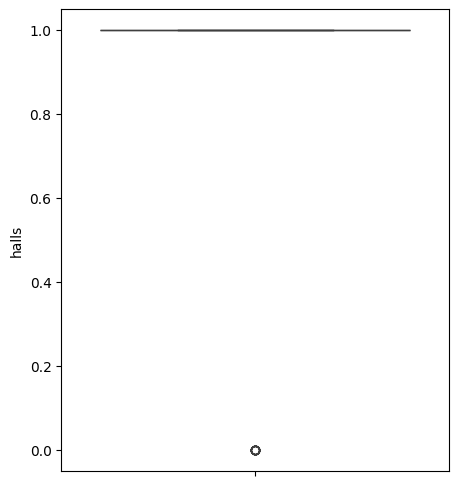

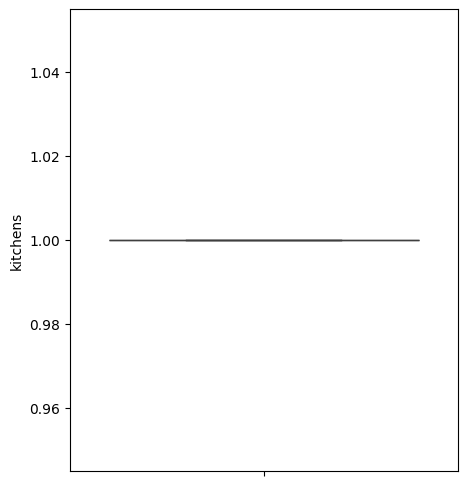

In [54]:
for i in num_col:
    plt.figure(figsize=(5,6))
    sns.boxplot(df[i])

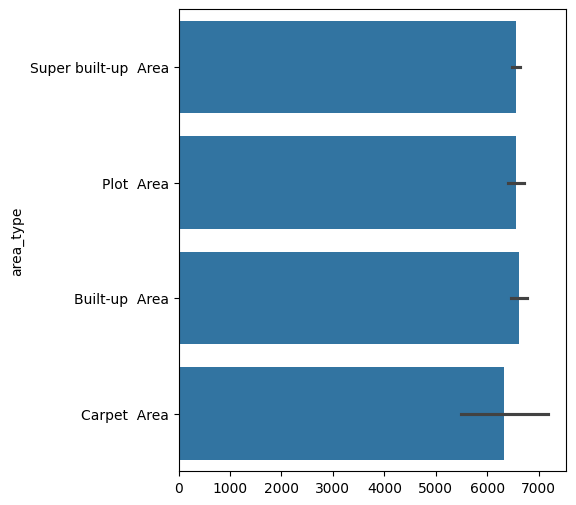

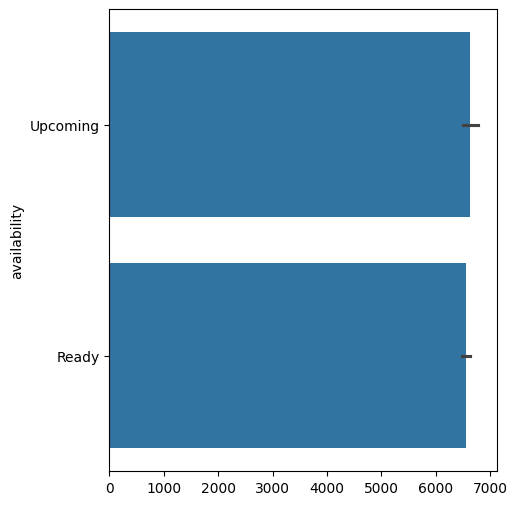

In [55]:
for c in ['area_type', 'availability']:
    plt.figure(figsize=(5,6))
    sns.barplot(df[c])

# Bivariate analysis :


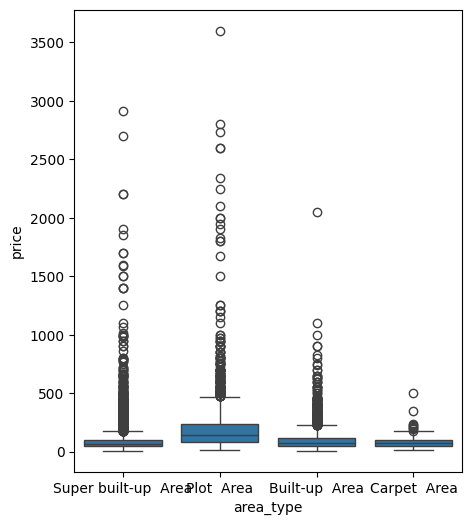

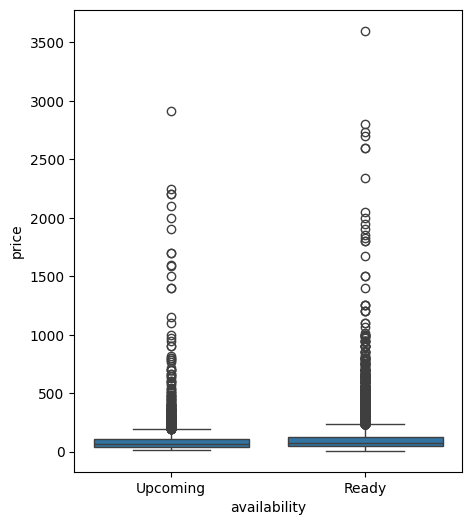

In [56]:


for col in ['area_type', 'availability']:
    plt.figure(figsize=(5,6))
    sns.boxplot(data=df, x=col, y="price")

<Axes: ylabel='location'>

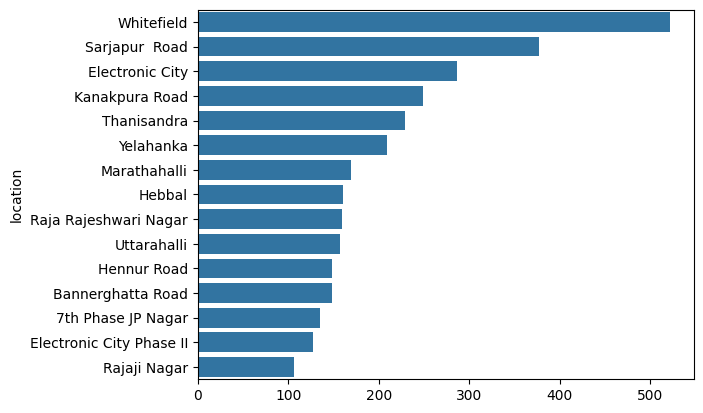

In [57]:
loc_counts = df["location"].value_counts()
sns.barplot(x=loc_counts.head(15).values, y=loc_counts.head(15).index)

Text(0.5, 1.0, 'Top 10 (known) societies')

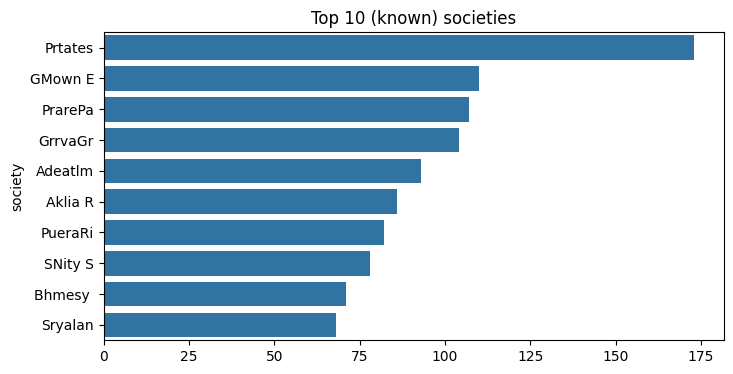

In [58]:
top_soc = df.loc[df["society"] != "unknown", "society"].value_counts().head(10)
plt.figure(figsize=(8, 4)); sns.barplot(x=top_soc.values, y=top_soc.index)
plt.title("Top 10 (known) societies")

# outliers detection and imputation 

In [59]:

def iqr_outlier(s):
    q1=s.quantile(.25)
    q3 = s.quantile(.75)
    iqr = q3-q1
    low = q1-1.5*iqr
    high = q3+1.5*iqr 
    return ((s<low)|(s>high)).sum(),low,high

In [60]:

report = []
for i in num_col :
    n,low,high = iqr_outlier(df[i])
    
    report.append([i,low,high,n,])

In [61]:
pd.DataFrame(report,columns=['column','lower_bound','iqr_upper','number_of_outliers'])

,column,lower_bound,iqr_upper,number_of_outliers
0,total_sqft,210.5,2582.5,1161
1,bath,0.5,4.5,1089
2,balcony,-0.5,3.5,589
3,price,-56.5,227.5,1255
4,bedrooms,0.5,4.5,852
5,halls,1.0,1.0,13
6,kitchens,1.0,1.0,0


In [62]:

print("Rows before:", len(df))
df["price_per_sqft"] = df["price"] * 100000 / df["total_sqft"]
mask = (
(df["total_sqft"] / df["bedrooms"].clip(lower=1) >= 300) &
(df["bath"] <= df["bedrooms"] + 2) &
(df["total_sqft"] <= 8000) &
(df["price_per_sqft"].between(2000, 25000)))
df = df[mask].drop(columns=["price_per_sqft"])
print("Rows after:", len(df))

Rows before: 12775
Rows after: 11881


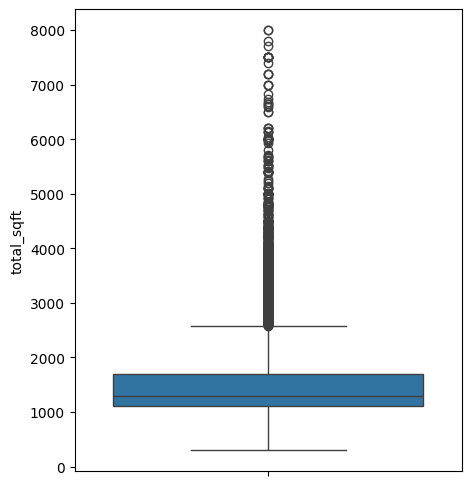

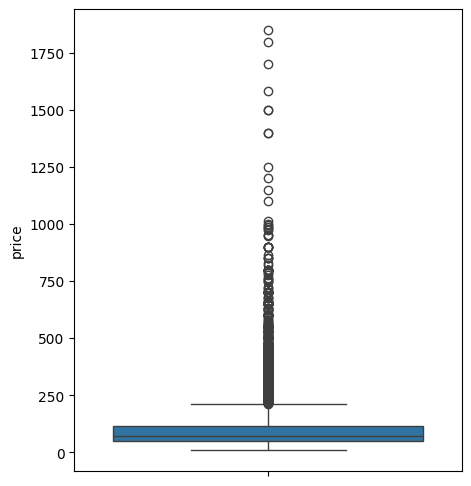

In [63]:
for i in ["total_sqft","price"]:
    plt.figure(figsize=(5,6))
    sns.boxplot(df[i])

# multivariate analysis 

<Axes: >

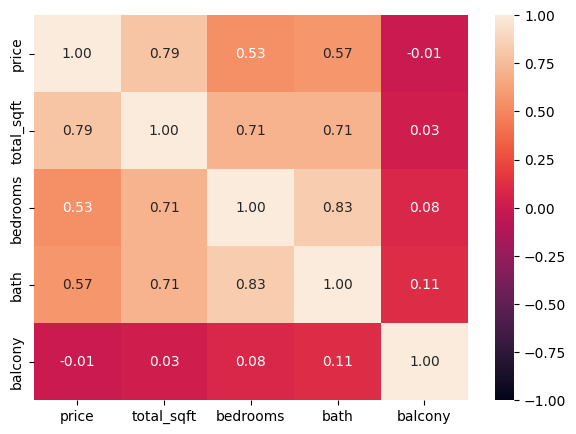

In [64]:
corr_cols = ["price", "total_sqft", "bedrooms", "bath", "balcony"]

plt.figure(figsize=(7, 5))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f",vmax=1,vmin=-1)

# encoding 

In [65]:
freq = df["society"].value_counts()
df["society_freq"] = df["society"].map(freq)

In [66]:
df["society_freq"]

0         5
1        15
2        80
3        22
4        52
         ..
13314     5
13315     5
13316     4
13317     2
13318     3
Name: society_freq, Length: 11881, dtype: int64

In [67]:
df["location"].nunique()

1200

In [68]:

df["location"] = df["location"].str.strip()
df["location"].nunique()

1190

In [69]:
df["location"].value_counts().describe()

count    1190.000000
mean        9.984034
std        28.670347
min         1.000000
25%         1.000000
50%         2.500000
75%         7.000000
max       518.000000
Name: count, dtype: float64

In [70]:
loc_counts = df["location"].value_counts()
df["location"] = df["location"].apply(
lambda x: x if loc_counts[x] >= 10 else "Other"
)

In [71]:
df["area_type"].value_counts()

area_type
Super built-up  Area    8234
Built-up  Area          2309
Plot  Area              1256
Carpet  Area              82
Name: count, dtype: int64

In [72]:
df

,area_type,availability,location,society,total_sqft,bath,balcony,price,bedrooms,halls,kitchens,society_freq
0,Super built-up Area,Upcoming,Electronic City Phase II,Coomee,1056.0,2.0,1.0,39.07,2,1,1,5
1,Plot Area,Ready,Chikka Tirupathi,Theanmp,2600.0,5.0,3.0,120.00,4,1,1,15
2,Built-up Area,Ready,Uttarahalli,Aklia R,1440.0,2.0,3.0,62.00,3,1,1,80
3,Super built-up Area,Ready,Lingadheeranahalli,Soiewre,1521.0,3.0,1.0,95.00,3,1,1,22
4,Super built-up Area,Ready,Kothanur,Somumys,1200.0,2.0,1.0,51.00,2,1,1,52
...,...,...,...,...,...,...,...,...,...,...,...,...
13314,Super built-up Area,Ready,Green Glen Layout,SoosePr,1715.0,3.0,3.0,112.00,3,1,1,5
13315,Built-up Area,Ready,Whitefield,ArsiaEx,3453.0,4.0,0.0,231.00,5,1,1,5
13316,Super built-up Area,Ready,Other,Alnorrm,3600.0,5.0,-1.0,400.00,4,1,1,4
13317,Built-up Area,Ready,Raja Rajeshwari Nagar,Mahla T,1141.0,2.0,1.0,60.00,2,1,1,2


In [73]:
df = pd.get_dummies(df, columns=["area_type", "location"], drop_first=True)
df.shape

(11881, 239)

In [74]:
df["availability_enc"] = (df["availability"] == "Ready").astype(int)

In [75]:
df = df.drop(["availability", "society", "halls", "kitchens"], axis=1)

In [76]:
df = df.astype(float)

In [77]:
df

,total_sqft,bath,balcony,price,bedrooms,society_freq,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_1st Phase JP Nagar,...,location_Vidyaranyapura,location_Vijayanagar,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,availability_enc
0,1056.0,2.0,1.0,39.07,2.0,5.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2600.0,5.0,3.0,120.00,4.0,15.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1440.0,2.0,3.0,62.00,3.0,80.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1521.0,3.0,1.0,95.00,3.0,22.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1200.0,2.0,1.0,51.00,2.0,52.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13314,1715.0,3.0,3.0,112.00,3.0,5.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
13315,3453.0,4.0,0.0,231.00,5.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
13316,3600.0,5.0,-1.0,400.00,4.0,4.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
13317,1141.0,2.0,1.0,60.00,2.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [78]:
df.head()

,total_sqft,bath,balcony,price,bedrooms,society_freq,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_1st Phase JP Nagar,...,location_Vidyaranyapura,location_Vijayanagar,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,availability_enc
0,1056.0,2.0,1.0,39.07,2.0,5.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2600.0,5.0,3.0,120.00,4.0,15.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1440.0,2.0,3.0,62.00,3.0,80.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1521.0,3.0,1.0,95.00,3.0,22.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1200.0,2.0,1.0,51.00,2.0,52.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [79]:
df

,total_sqft,bath,balcony,price,bedrooms,society_freq,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_1st Phase JP Nagar,...,location_Vidyaranyapura,location_Vijayanagar,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,availability_enc
0,1056.0,2.0,1.0,39.07,2.0,5.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2600.0,5.0,3.0,120.00,4.0,15.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1440.0,2.0,3.0,62.00,3.0,80.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1521.0,3.0,1.0,95.00,3.0,22.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1200.0,2.0,1.0,51.00,2.0,52.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13314,1715.0,3.0,3.0,112.00,3.0,5.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
13315,3453.0,4.0,0.0,231.00,5.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
13316,3600.0,5.0,-1.0,400.00,4.0,4.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
13317,1141.0,2.0,1.0,60.00,2.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


price per sqft 


# model traininig (linear Regression)

In [80]:
x = df.drop(["price"],axis = 1)
y = df["price"]

In [81]:
from sklearn.model_selection import train_test_split

In [82]:
x_train, x_test, y_train, y_test = train_test_split(
x, y,test_size=0.33,random_state=42)

In [83]:
from sklearn.linear_model import LinearRegression

In [84]:
model = LinearRegression()


In [85]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [86]:
y_pred = model.predict(x_test)

In [87]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test,y_pred)
r2


0.7232557093689019

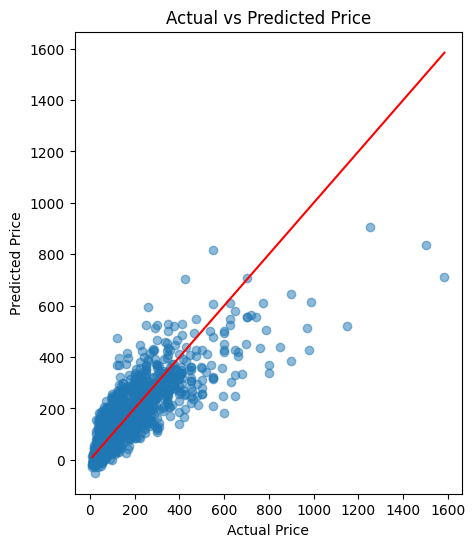

In [88]:
plt.figure(figsize=(5,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.plot(
[y_test.min(), y_test.max()],
[y_test.min(), y_test.max()],
color='red'
)
plt.show()

In [89]:
df.to_csv("cleaned.csv")